# MTR=0.5 vs 0.7 Detailed Decode Analysis (rewarm fb on, GSM8K)

Run `mid_trigger_ratio = 0.5` and `0.7` on 200 samples, analyze:

| Metric | Definition |
|--------|-----------|
| **Decode Rate** | Avg tokens decoded per step |
| **Big-block Confidence** | Decoded ratio in current working region: `1 - remaining / range_size` |
| **Per-step Decode Fraction** | `transferred / range_size`, single-step contribution to current big block |

**Key question: Does opening a new block (expand) boost decoding speed?**
- Align all chains at expand event = t=0
- Compare the two ratios before/after expand: confidence, speed, efficiency

## 1. Environment Setup

In [1]:
import os
import torch
import gc

os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3,4,5,6,7'

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_ALLOW_CODE_EVAL'] = '1'
os.environ['HF_DATASETS_TRUST_REMOTE_CODE'] = 'true'

os.chdir('llada')

os.makedirs('nlogs', exist_ok=True)

torch.cuda.empty_cache()
gc.collect()

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} "
          f"({torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB)")

CUDA available: True
GPU count: 7
  GPU 0: NVIDIA RTX A5000 (23.5 GB)
  GPU 1: NVIDIA RTX A5000 (22.1 GB)
  GPU 2: NVIDIA RTX A5000 (22.1 GB)
  GPU 3: NVIDIA RTX A5000 (22.1 GB)
  GPU 4: NVIDIA RTX A5000 (22.1 GB)
  GPU 5: NVIDIA RTX A5000 (22.1 GB)
  GPU 6: NVIDIA RTX A5000 (22.1 GB)


## 2. Experiment Config (ratio=0.5 / 0.7 only, 200 samples)

In [2]:
import subprocess
import datetime
import threading
import queue
import numpy as np

# ========== Target ratios ==========
SWEEP_VALUES = [0.5, 0.7]

# ========== GPU pool (one GPU per ratio, run in parallel) ==========
GPU_POOL = [2, 1]

# ========== Eval params (identical to expand_rewarm_fb_on) ==========
task = "gsm8k"
fewshot = 5
limit = 200        # 200 samples
seed = 42
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

gen_length = 256
steps = 256
block_length = 32
threshold = 0.9

FIXED_DUAL_CACHE = True
FIXED_MID_BLOCK_EXPAND = True
FIXED_REWARM = True               # rewarm_on_expand=True
FIXED_FALLBACK = True              # front_block_fallback_only=True

print(f"Target ratios: {SWEEP_VALUES}")
print(f"GPU pool: {GPU_POOL}")
print(f"limit: {limit} samples")
print(f"Timestamp: {timestamp}")

Target ratios: [0.5, 0.7]
GPU pool: [2, 1]
limit: 200 samples
Timestamp: 20260225_174103


## 3. Launch Experiments

In [3]:
task_queue = queue.Queue()
for ratio in SWEEP_VALUES:
    task_queue.put(ratio)

results_lock = threading.Lock()
all_results = []


def gpu_worker(gpu_id):
    """GPU worker: pull tasks from queue until empty."""
    while True:
        try:
            ratio = task_queue.get_nowait()
        except queue.Empty:
            return

        name = f"ratio_{ratio:.2f}"
        log_file = f"nlogs/mtr_detail_{task}_{name}_{timestamp}.log"
        output_dir = f"evals_results/mtr_detail/{task}-{name}-{timestamp}"
        records_dir = f"{output_dir}/step_records"

        extra_args = [
            f"dual_cache={FIXED_DUAL_CACHE}",
            f"mid_block_expand={FIXED_MID_BLOCK_EXPAND}",
            f"mid_trigger_ratio={ratio}",
            f"rewarm_on_expand={FIXED_REWARM}",
            f"front_block_fallback_only={FIXED_FALLBACK}",
        ]

        base_args = [
            f"model_path='GSAI-ML/LLaDA-8B-Instruct'",
            f"gen_length={gen_length}",
            f"steps={steps}",
            f"block_length={block_length}",
            f"threshold={threshold}",
            "use_cache=True",
            "show_speed=True",
            f"step_records_dir='{records_dir}'",
            f"seed={seed}",
        ]
        all_args = base_args + extra_args
        model_args_str = ",".join(all_args)

        limit_str = f" --limit {limit}" if limit is not None else ""
        cmd = (
            f"CUDA_VISIBLE_DEVICES={gpu_id} accelerate launch eval_llada.py "
            f"--tasks {task} --num_fewshot {fewshot}{limit_str} "
            f"--confirm_run_unsafe_code --model llada_dist "
            f"--model_args {model_args_str} "
            f"--output_path {output_dir} --log_samples"
        )

        print(f"[GPU {gpu_id}] START  mid_trigger_ratio={ratio:.2f}")

        p = subprocess.Popen(
            cmd, shell=True,
            stdout=open(log_file, "w"),
            stderr=subprocess.STDOUT,
        )
        rc = p.wait()

        status = "OK" if rc == 0 else f"FAILED(exit={rc})"
        print(f"[GPU {gpu_id}] DONE   mid_trigger_ratio={ratio:.2f}  {status}")

        with results_lock:
            all_results.append((ratio, name, log_file, output_dir, rc))

        task_queue.task_done()


threads = []
for gpu_id in GPU_POOL:
    t = threading.Thread(target=gpu_worker, args=(gpu_id,), daemon=True)
    t.start()
    threads.append(t)

print(f"Launched {len(threads)} GPU workers for {len(SWEEP_VALUES)} tasks. Waiting...")

[GPU 2] START  mid_trigger_ratio=0.50
[GPU 1] START  mid_trigger_ratio=0.70
Launched 2 GPU workers for 2 tasks. Waiting...
[GPU 1] DONE   mid_trigger_ratio=0.70  OK
[GPU 2] DONE   mid_trigger_ratio=0.50  OK


In [4]:
for t in threads:
    t.join()

print(f"\nAll {len(all_results)} / {len(SWEEP_VALUES)} tasks finished.")
all_results.sort(key=lambda x: x[0])
for ratio, name, log_file, output_dir, rc in all_results:
    status = "OK" if rc == 0 else f"FAILED(exit={rc})"
    print(f"  ratio={ratio:.2f}  {status}  log={log_file}")


All 2 / 2 tasks finished.
  ratio=0.50  OK  log=nlogs/mtr_detail_gsm8k_ratio_0.50_20260225_174103.log
  ratio=0.70  OK  log=nlogs/mtr_detail_gsm8k_ratio_0.70_20260225_174103.log


## 4. Parse Logs + Load step_records

In [5]:
import glob, re, json
import pandas as pd

# ---------- Parse log files ----------
config_names = [f"ratio_{r:.2f}" for r in SWEEP_VALUES]

parsed_results = []
for name in config_names:
    log_file = f"nlogs/mtr_detail_{task}_{name}_{timestamp}.log"
    if not os.path.exists(log_file):
        print(f"[MISS] {log_file}")
        continue
    with open(log_file, 'r') as f:
        content = f.read()

    ratio_val = float(name.replace("ratio_", ""))
    acc_match = re.search(r'exact_match.*?[\|,]\s*[\|]?\s*([\d.]+)', content)
    nfe_match = re.search(r'Total NFE is (\d+)', content)
    time_match = re.search(r'Total time taken:\s*([\d.]+)', content)
    speed_match = re.search(r'Tokens per second:\s*([\d.]+)', content)

    parsed_results.append({
        'ratio': ratio_val,
        'config': name,
        'accuracy': float(acc_match.group(1)) if acc_match else None,
        'total_nfe': int(nfe_match.group(1)) if nfe_match else None,
        'time_sec': float(time_match.group(1)) if time_match else None,
        'tokens_per_sec': float(speed_match.group(1)) if speed_match else None,
    })

parsed_results.sort(key=lambda x: x['ratio'])
print("Parsed results:")
for r in parsed_results:
    print(f"  ratio={r['ratio']:.2f}  acc={r['accuracy']}  nfe={r['total_nfe']}  tok/s={r['tokens_per_sec']}")

# ---------- Load step_records ----------
step_data = {}
for name in config_names:
    rpath = f"evals_results/mtr_detail/{task}-{name}-{timestamp}/step_records/step_records.json"
    if os.path.exists(rpath):
        with open(rpath, 'r') as f:
            step_data[name] = json.load(f)
        print(f"[OK]  {name}: {len(step_data[name])} samples, "
              f"{sum(len(s) for s in step_data[name])} total steps")
    else:
        print(f"[MISS] {rpath}")

print(f"\nLoaded step_records for {len(step_data)}/{len(config_names)} configs.")

Parsed results:
  ratio=0.50  acc=0.77  nfe=14790  tok/s=30.751882553100586
  ratio=0.70  acc=0.775  nfe=14668  tok/s=32.941001892089844
[OK]  ratio_0.50: 200 samples, 14790 total steps
[OK]  ratio_0.70: 200 samples, 14668 total steps

Loaded step_records for 2/2 configs.


## 4.5 Reload from Existing Results (skip experiments, go straight to analysis)

If experiments were already run, modify `timestamp` below or let auto-detection find it.

In [ ]:
import glob, re, json, os
import numpy as np
import pandas as pd

task = "gsm8k"
gen_length = 256
block_length = 32
SWEEP_VALUES = [0.5, 0.7]
config_names = [f"ratio_{r:.2f}" for r in SWEEP_VALUES]

# Auto-detect latest timestamp
latest_logs = sorted(
    glob.glob(f"nlogs/mtr_detail_{task}_{config_names[0]}_*.log"),
    key=os.path.getmtime, reverse=True,
)
if latest_logs:
    fname = os.path.basename(latest_logs[0])
    timestamp = fname.replace(f"mtr_detail_{task}_{config_names[0]}_", "").replace(".log", "")
    print(f"Auto-detected latest timestamp: {timestamp}")
else:
    timestamp = "NOTFOUND"
    print("WARNING: No log found! Set timestamp manually.")

# Load step_data
step_data = {}
for name in config_names:
    rpath = f"evals_results/mtr_detail/{task}-{name}-{timestamp}/step_records/step_records.json"
    if os.path.exists(rpath):
        with open(rpath, 'r') as f:
            step_data[name] = json.load(f)
        print(f"  [OK]  {name}: {len(step_data[name])} samples, "
              f"{sum(len(s) for s in step_data[name])} total steps")
    else:
        print(f"  [MISS] {name}: {rpath}")

# Load parsed_results
parsed_results = []
for name in config_names:
    log_file = f"nlogs/mtr_detail_{task}_{name}_{timestamp}.log"
    if not os.path.exists(log_file):
        continue
    with open(log_file, 'r') as f:
        content = f.read()
    ratio_val = float(name.replace("ratio_", ""))
    acc_match = re.search(r'exact_match.*?[\|,]\s*[\|]?\s*([\d.]+)', content)
    nfe_match = re.search(r'Total NFE is (\d+)', content)
    time_match = re.search(r'Total time taken:\s*([\d.]+)', content)
    speed_match = re.search(r'Tokens per second:\s*([\d.]+)', content)
    parsed_results.append({
        'ratio': ratio_val, 'config': name,
        'accuracy': float(acc_match.group(1)) if acc_match else None,
        'total_nfe': int(nfe_match.group(1)) if nfe_match else None,
        'time_sec': float(time_match.group(1)) if time_match else None,
        'tokens_per_sec': float(speed_match.group(1)) if speed_match else None,
    })
parsed_results.sort(key=lambda x: x['ratio'])

print(f"\nLoaded {len(step_data)} step_data, {len(parsed_results)} parsed_results")

## 5. Metric Computation (big-block chain grouping)

Each `type='warm'` starts a new **big-block chain**. A chain may cover a single block (no expand) or span 2-3 blocks via chained expansions.

In [6]:
from collections import defaultdict

BLOCK_LENGTH = 32
TARGET_RATIOS = [0.5, 0.7]


def split_into_chains(sample_records):
    """Split at each type='warm' to form one chain per big-block cycle."""
    chains, cur = [], []
    for rec in sample_records:
        if rec['type'] == 'warm' and cur:
            chains.append(cur)
            cur = [rec]
        else:
            cur.append(rec)
    if cur:
        chains.append(cur)
    return chains


def analyse_chain(chain):
    """Compute per-step metrics for one chain, return dict."""
    n_steps = len(chain)
    total_transferred = sum(r['transferred'] for r in chain)

    step_details = []
    for si, rec in enumerate(chain):
        rng_size = rec['range'][1] - rec['range'][0]
        conf = 1.0 - rec['remaining'] / rng_size if rng_size > 0 else 1.0
        dfrac = rec['transferred'] / rng_size if rng_size > 0 else 0.0
        step_details.append({
            'step_in_chain': si,
            'type': rec['type'],
            'transferred': rec['transferred'],
            'remaining': rec['remaining'],
            'range_size': rng_size,
            'confidence': conf,
            'decode_frac': dfrac,
        })

    has_expand = any(r['type'] == 'expand' for r in chain)
    expand_idx = next((i for i, r in enumerate(chain) if r['type'] == 'expand'), None)
    final_rng = chain[-1]['range']

    return {
        'n_steps': n_steps,
        'total_transferred': total_transferred,
        'final_block_size': final_rng[1] - final_rng[0],
        'avg_tokens_per_step': total_transferred / n_steps if n_steps else 0,
        'final_confidence': step_details[-1]['confidence'],
        'has_expand': has_expand,
        'expand_step_idx': expand_idx,
        'step_details': step_details,
    }


# ---------- Main loop ----------
all_stats = {}

for ratio in TARGET_RATIOS:
    key = f"ratio_{ratio:.2f}"
    if key not in step_data:
        print(f"[SKIP] {key} — no data")
        continue

    chain_list = []
    for si, sample_recs in enumerate(step_data[key]):
        for ci, chain in enumerate(split_into_chains(sample_recs)):
            info = analyse_chain(chain)
            info['sample'] = si
            info['chain_idx'] = ci
            chain_list.append(info)

    all_stats[ratio] = chain_list

    # Summary
    avg_tok = np.mean([c['avg_tokens_per_step'] for c in chain_list])
    med_tok = np.median([c['avg_tokens_per_step'] for c in chain_list])
    avg_conf = np.mean([c['final_confidence'] for c in chain_list])
    n_expand = sum(1 for c in chain_list if c['has_expand'])
    all_fracs = [sd['decode_frac'] for c in chain_list for sd in c['step_details']]

    print(f"\n{'='*60}")
    print(f"ratio={ratio:.2f}  |  {len(chain_list)} big-block chains  |  "
          f"expand chains: {n_expand} ({100*n_expand/len(chain_list):.1f}%)")
    print(f"  decode rate     mean={avg_tok:.2f}  median={med_tok:.2f}  tokens/step")
    print(f"  final conf      mean={avg_conf:.4f}")
    print(f"  per-step frac   mean={np.mean(all_fracs):.4f}  median={np.median(all_fracs):.4f}")


ratio=0.50  |  264 big-block chains  |  expand chains: 226 (85.6%)
  解码速率      mean=6.25  median=3.61  tokens/step
  最终信心      mean=0.9999
  per-step frac mean=0.0719  median=0.0250

ratio=0.70  |  241 big-block chains  |  expand chains: 218 (90.5%)
  解码速率      mean=6.06  median=3.71  tokens/step
  最终信心      mean=0.9988
  per-step frac mean=0.0645  median=0.0204


## 6. Per-step Visualization: Decode Rate / Confidence / Decode Fraction

- **Left / Mid column**: Per-step confidence curve & decode fraction for ratio=0.5 / 0.7
- **Right column**: Decode rate box comparison + final confidence histogram

/data/houpu/tmp/ipykernel_2968893/2830348726.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5)
/data/houpu/tmp/ipykernel_2968893/2830348726.py:88: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/2830348726.py:88: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/2830348726.py:88: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/2830348726.py:88: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/2830348

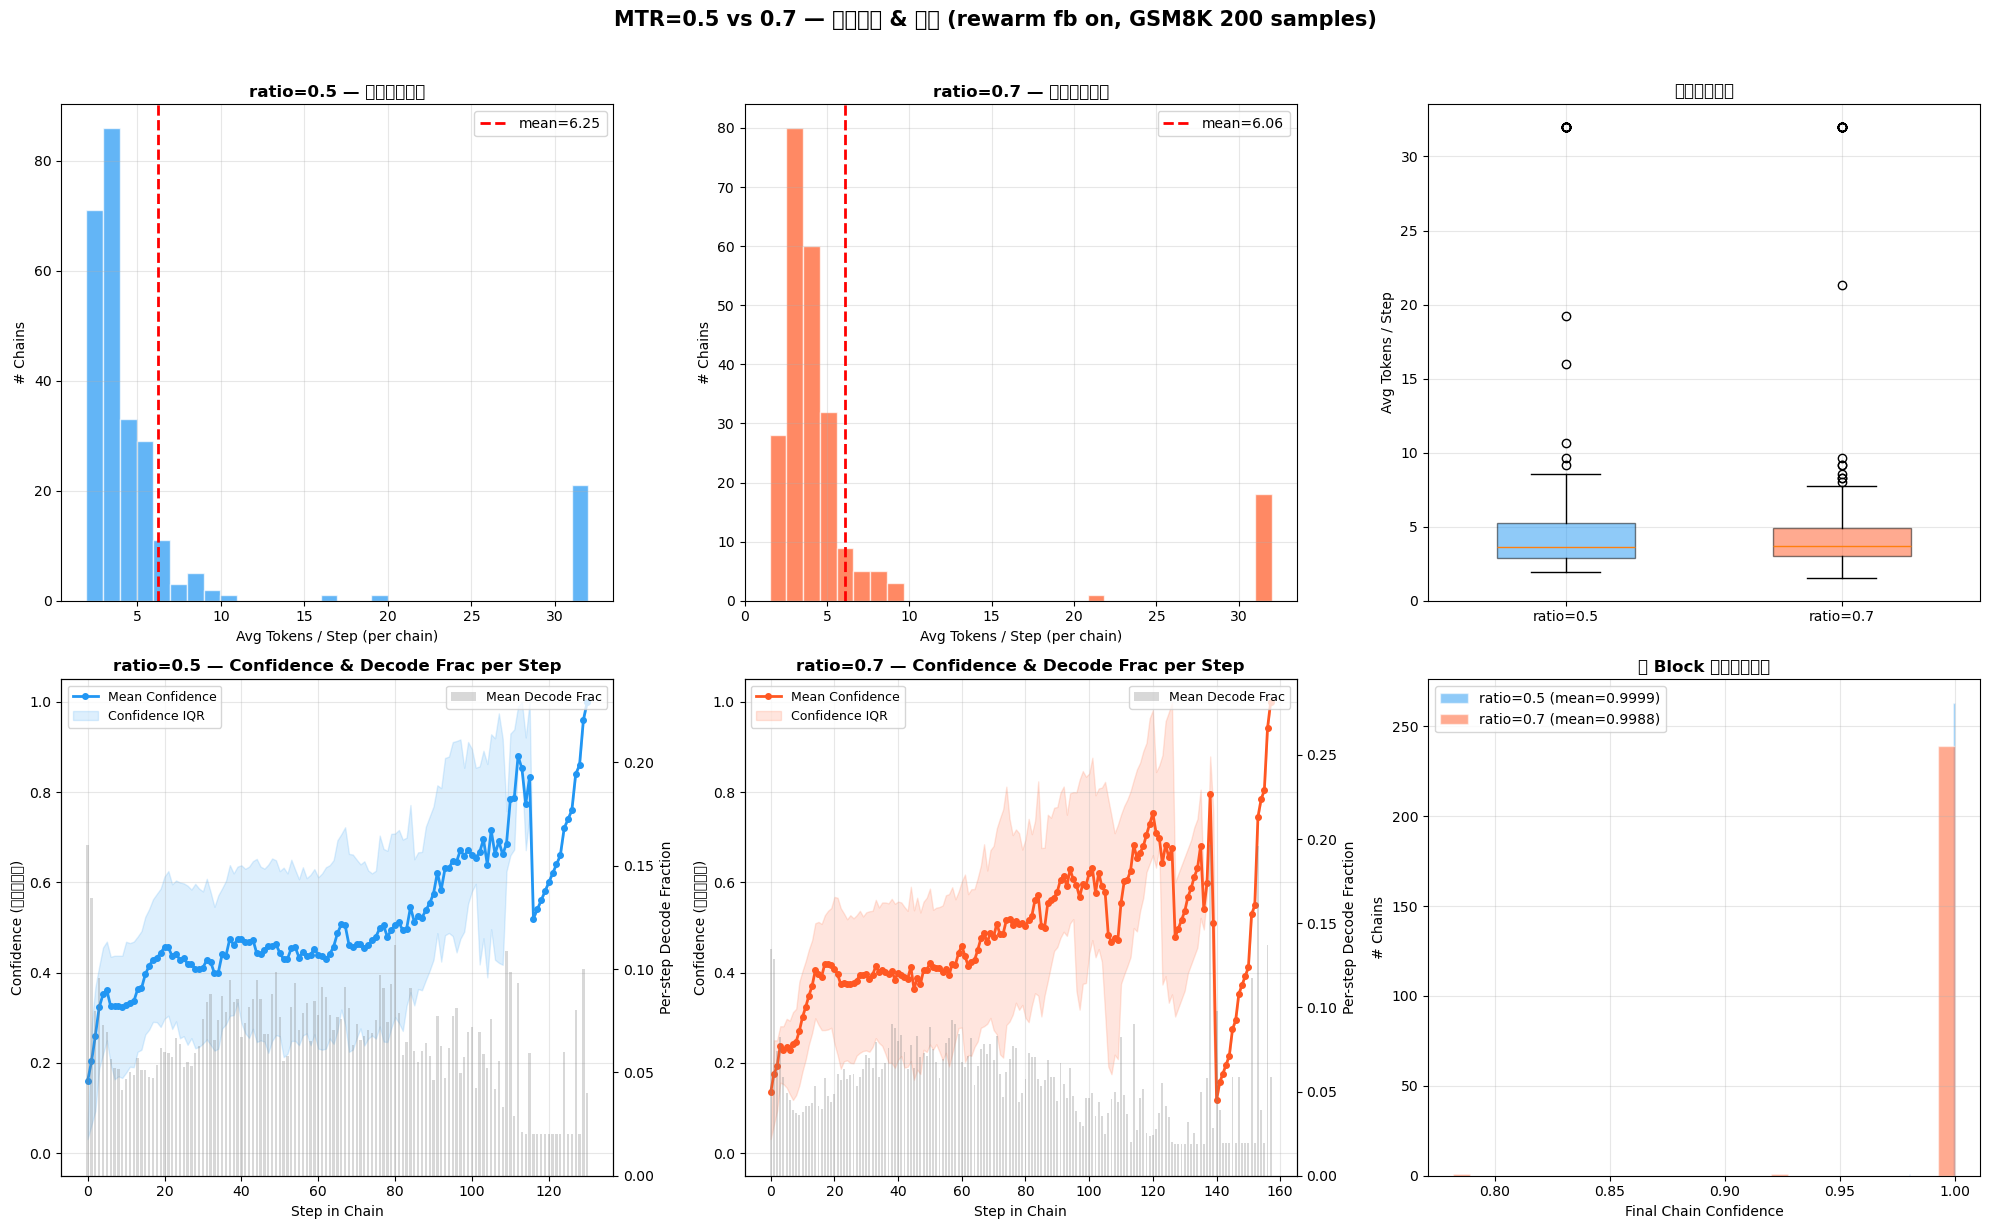

Saved: eval_results/mtr_detail_perstep.png


In [7]:
import matplotlib.pyplot as plt

COLORS = {0.5: '#2196F3', 0.7: '#FF5722'}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, ratio in enumerate(TARGET_RATIOS):
    if ratio not in all_stats:
        continue
    chains = all_stats[ratio]
    c = COLORS[ratio]

    # ---- Row 0: Decode rate histogram ----
    ax = axes[0, col]
    tok_ps = [ch['avg_tokens_per_step'] for ch in chains]
    ax.hist(tok_ps, bins=30, color=c, alpha=0.7, edgecolor='white')
    mu = np.mean(tok_ps)
    ax.axvline(mu, color='red', ls='--', lw=2, label=f'mean={mu:.2f}')
    ax.set_xlabel('Avg Tokens / Step (per chain)')
    ax.set_ylabel('# Chains')
    ax.set_title(f'ratio={ratio} - Decode Rate Distribution', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- Row 1: Confidence + Decode Fraction vs step ----
    ax = axes[1, col]
    step_confs = defaultdict(list)
    step_fracs = defaultdict(list)
    for ch in chains:
        for sd in ch['step_details']:
            step_confs[sd['step_in_chain']].append(sd['confidence'])
            step_fracs[sd['step_in_chain']].append(sd['decode_frac'])

    steps_sorted = sorted(step_confs.keys())
    mean_confs = [np.mean(step_confs[s]) for s in steps_sorted]
    mean_fracs = [np.mean(step_fracs[s]) for s in steps_sorted]

    ax.plot(steps_sorted, mean_confs, 'o-', color=c, lw=2, ms=4, label='Mean Confidence')
    ax.fill_between(steps_sorted,
                     [np.percentile(step_confs[s], 25) for s in steps_sorted],
                     [np.percentile(step_confs[s], 75) for s in steps_sorted],
                     color=c, alpha=0.15, label='Confidence IQR')
    ax.set_xlabel('Step in Chain')
    ax.set_ylabel('Confidence (decoded ratio)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

    ax2 = ax.twinx()
    ax2.bar(steps_sorted, mean_fracs, alpha=0.3, color='gray', width=0.6,
            label='Mean Decode Frac')
    ax2.set_ylabel('Per-step Decode Fraction')
    ax2.set_ylim(0, max(mean_fracs) * 1.5 if mean_fracs else 1)
    ax2.legend(loc='upper right', fontsize=9)
    ax.set_title(f'ratio={ratio} - Confidence & Decode Frac per Step', fontweight='bold')

# ---- Row 0, Col 2: Decode rate box comparison ----
ax = axes[0, 2]
box_data, box_labels = [], []
for ratio in TARGET_RATIOS:
    if ratio in all_stats:
        box_data.append([ch['avg_tokens_per_step'] for ch in all_stats[ratio]])
        box_labels.append(f'ratio={ratio}')
bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True, widths=0.5)
for patch, ratio in zip(bp['boxes'], TARGET_RATIOS):
    patch.set_facecolor(COLORS.get(ratio, 'gray'))
    patch.set_alpha(0.5)
ax.set_ylabel('Avg Tokens / Step')
ax.set_title('Decode Rate Comparison', fontweight='bold')
ax.grid(True, alpha=0.3)

# ---- Row 1, Col 2: Final confidence comparison ----
ax = axes[1, 2]
for ratio in TARGET_RATIOS:
    if ratio not in all_stats:
        continue
    confs = [ch['final_confidence'] for ch in all_stats[ratio]]
    ax.hist(confs, bins=30, color=COLORS[ratio], alpha=0.5,
            label=f'ratio={ratio} (mean={np.mean(confs):.4f})', edgecolor='white')
ax.set_xlabel('Final Chain Confidence')
ax.set_ylabel('# Chains')
ax.set_title('Final Big-Block Confidence Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('MTR=0.5 vs 0.7 - Decode Rate & Confidence (rewarm fb on, GSM8K 200 samples)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../eval_results', exist_ok=True)
plt.savefig('../eval_results/mtr_detail_perstep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_results/mtr_detail_perstep.png")

## 7. Expand-Aligned Speed Analysis (Key Plot)

**Core question: Does expanding (opening a new block) produce a speed boost?**

- Select only chains with an expand event
- Align at expand step = **t=0**: left = pre-expand (warm/refine), right = post-expand (refine)
- 4 subplots:
  1. **Transferred tokens / step**: absolute decode speed before vs after expand
  2. **Decode fraction** (transferred / range_size): relative efficiency
  3. **Confidence** trajectory: how decoded ratio evolves around expand
  4. **Range size** jump: working region doubles at expand

ratio=0.5: 226 chains with expand, relative steps range [-16, 126]
ratio=0.7: 218 chains with expand, relative steps range [-10, 149]


/data/houpu/tmp/ipykernel_2968893/1366475998.py:69: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/1366475998.py:69: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/1366475998.py:69: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/1366475998.py:69: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/1366475998.py:69: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/houpu/tmp/ipykernel_2968893/1366475998.py:70: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  plt.savefig('../eval_results/

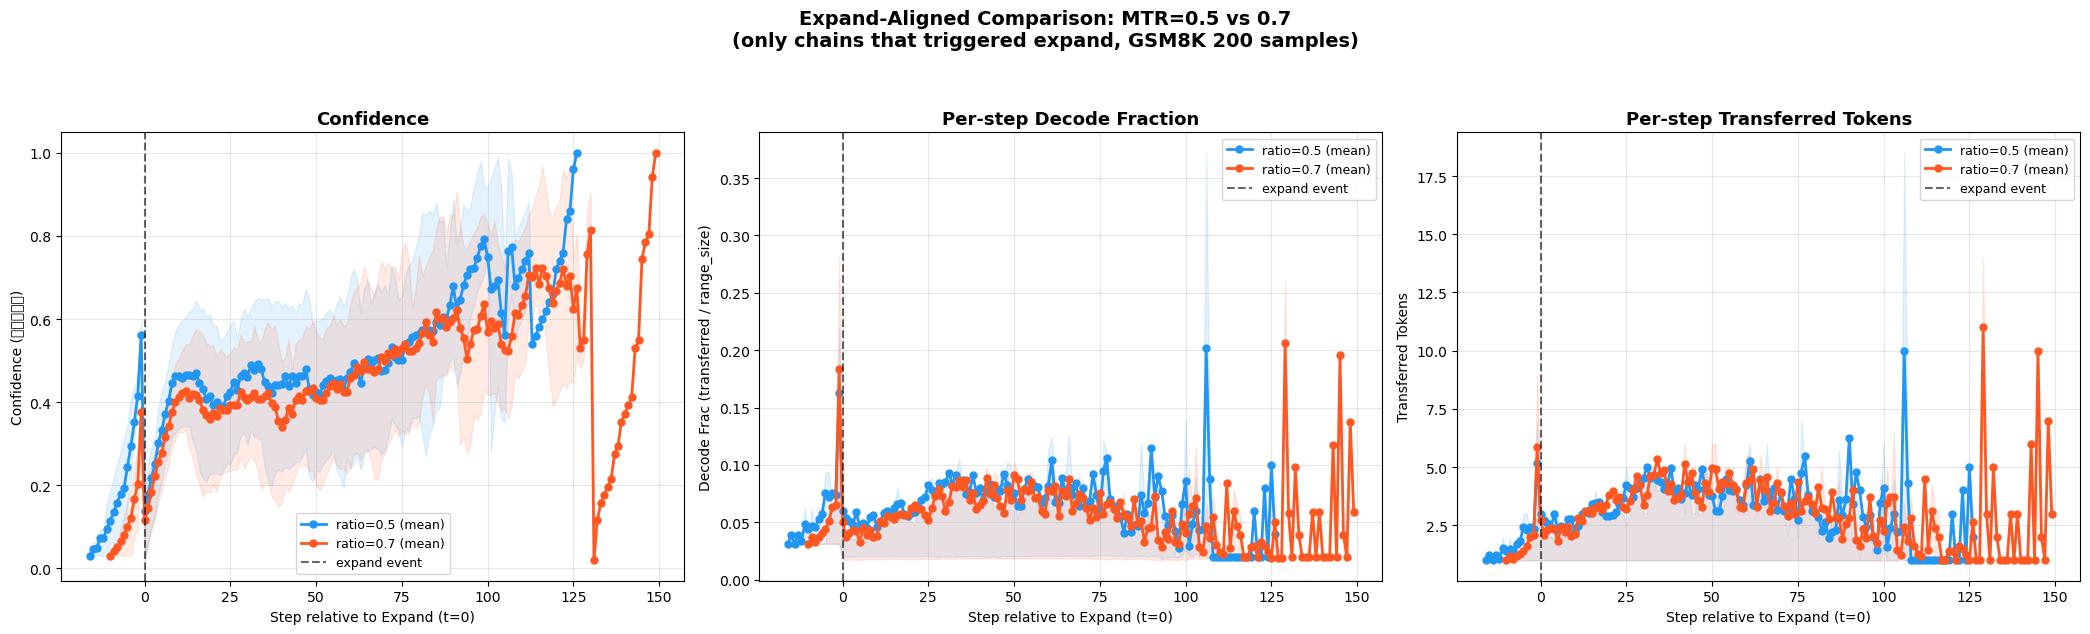

Saved: eval_results/mtr_detail_expand_aligned.png


In [8]:
def build_expand_aligned(chain_list):
    """Align chains by expand step (t=0). Returns dict: rel_step -> list of record dicts."""
    aligned = defaultdict(list)
    for ch in chain_list:
        if not ch['has_expand']:
            continue
        t0 = ch['expand_step_idx']
        for sd in ch['step_details']:
            rel = sd['step_in_chain'] - t0
            aligned[rel].append({
                'confidence': sd['confidence'],
                'decode_frac': sd['decode_frac'],
                'transferred': sd['transferred'],
                'type': sd['type'],
                'range_size': sd['range_size'],
            })
    return aligned


expand_aligned = {}
for ratio in TARGET_RATIOS:
    if ratio not in all_stats:
        continue
    aligned = build_expand_aligned(all_stats[ratio])
    expand_aligned[ratio] = aligned
    n_expand = sum(1 for c in all_stats[ratio] if c['has_expand'])
    print(f"ratio={ratio}: {n_expand} chains with expand, "
          f"relative steps range [{min(aligned.keys())}, {max(aligned.keys())}]")

# ---- Zoom window: focus on [-5, +15] around expand for clarity ----
ZOOM_LEFT, ZOOM_RIGHT = -5, 15

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plot_specs = [
    ('transferred', 'Transferred Tokens / Step',  'Transferred Tokens per Step (absolute speed)'),
    ('decode_frac', 'Decode Fraction (transferred / range_size)', 'Per-step Decode Fraction (relative efficiency)'),
    ('confidence',  'Confidence (decoded ratio)',  'Confidence Trajectory Around Expand'),
    ('range_size',  'Range Size (tokens)',         'Working Region Size Around Expand'),
]

for ax_idx, (ykey, ylabel, title) in enumerate(plot_specs):
    ax = axes[ax_idx // 2, ax_idx % 2]
    for ratio in TARGET_RATIOS:
        if ratio not in expand_aligned:
            continue
        aligned = expand_aligned[ratio]
        rel_steps = sorted(s for s in aligned.keys() if ZOOM_LEFT <= s <= ZOOM_RIGHT)
        if not rel_steps:
            continue

        vals_per_step = [[d[ykey] for d in aligned[s]] for s in rel_steps]
        means = [np.mean(v) for v in vals_per_step]
        q25 = [np.percentile(v, 25) for v in vals_per_step]
        q75 = [np.percentile(v, 75) for v in vals_per_step]
        counts = [len(v) for v in vals_per_step]

        c = COLORS[ratio]
        ax.plot(rel_steps, means, 'o-', color=c, lw=2, ms=5,
                label=f'ratio={ratio} (n={counts[0]}..{counts[-1]})')
        ax.fill_between(rel_steps, q25, q75, color=c, alpha=0.12)

    ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.6)
    ax.axvspan(-0.5, 0.5, color='gold', alpha=0.15, label='expand step')
    ax.set_xlabel('Step relative to Expand (t=0)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Expand-Aligned Analysis: MTR=0.5 vs 0.7  (zoom [-5, +15])\n'
             'Does opening a new block boost decoding speed?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../eval_results/mtr_detail_expand_aligned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_results/mtr_detail_expand_aligned.png")

## 8. Block-Level View: Per-Block Decode Speed

Instead of aligning by step, group by **original block index** (0..7).
For each block, compute:
- Total tokens decoded in that block
- Number of steps spent on that block
- Avg tokens / step for that block
- Whether the block was consumed via **expand** (chained from previous) or started fresh (**warm**)

This shows: blocks entered via expand (block 1, 2, ...) vs fresh-start blocks (block 0) — any speed difference?

In [ ]:
NUM_BLOCKS = gen_length // block_length  # 256 / 32 = 8

def build_per_block_stats(chain_list, step_data_samples):
    """
    For each original block (0..NUM_BLOCKS-1), aggregate:
    - how it was entered (warm vs expand)
    - total transferred, steps spent, avg tokens/step
    """
    block_records = defaultdict(list)  # block_idx -> list of dicts

    for sample_recs in step_data_samples:
        for rec in sample_recs:
            blk = rec['block']
            rng_size = rec['range'][1] - rec['range'][0]
            block_records[blk].append({
                'type': rec['type'],
                'transferred': rec['transferred'],
                'remaining': rec['remaining'],
                'range_size': rng_size,
            })

    stats = []
    for blk_idx in range(NUM_BLOCKS):
        recs = block_records.get(blk_idx, [])
        if not recs:
            continue
        total_trans = sum(r['transferred'] for r in recs)
        n_steps = len(recs)
        n_warm = sum(1 for r in recs if r['type'] == 'warm')
        n_expand = sum(1 for r in recs if r['type'] == 'expand')
        n_refine = sum(1 for r in recs if r['type'] == 'refine')
        avg_tps = total_trans / n_steps if n_steps else 0
        per_step_trans = [r['transferred'] for r in recs]

        stats.append({
            'block': blk_idx,
            'total_transferred': total_trans,
            'n_steps': n_steps,
            'avg_tokens_per_step': avg_tps,
            'median_tokens_per_step': np.median(per_step_trans),
            'n_warm': n_warm,
            'n_expand': n_expand,
            'n_refine': n_refine,
            'entry_mode': 'warm-dominant' if n_warm > n_expand else 'expand-dominant',
        })
    return stats


block_stats = {}
for ratio in TARGET_RATIOS:
    key = f"ratio_{ratio:.2f}"
    if key not in step_data:
        continue
    block_stats[ratio] = build_per_block_stats(all_stats[ratio], step_data[key])
    print(f"ratio={ratio}: {len(block_stats[ratio])} blocks with data")

# ---- Plot: per-block avg tokens/step ----
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Left: avg tokens/step per block
ax = axes[0]
bar_w = 0.35
for ri, ratio in enumerate(TARGET_RATIOS):
    if ratio not in block_stats:
        continue
    bs = block_stats[ratio]
    blocks = [b['block'] for b in bs]
    avg_tps = [b['avg_tokens_per_step'] for b in bs]
    offset = -bar_w / 2 + ri * bar_w
    ax.bar(np.array(blocks) + offset, avg_tps, bar_w, color=COLORS[ratio],
           alpha=0.7, label=f'ratio={ratio}', edgecolor='white')

ax.set_xlabel('Original Block Index')
ax.set_ylabel('Avg Tokens / Step')
ax.set_title('Avg Decode Speed per Block', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Mid: n_steps per block
ax = axes[1]
for ri, ratio in enumerate(TARGET_RATIOS):
    if ratio not in block_stats:
        continue
    bs = block_stats[ratio]
    blocks = [b['block'] for b in bs]
    n_steps = [b['n_steps'] for b in bs]
    offset = -bar_w / 2 + ri * bar_w
    ax.bar(np.array(blocks) + offset, n_steps, bar_w, color=COLORS[ratio],
           alpha=0.7, label=f'ratio={ratio}', edgecolor='white')

ax.set_xlabel('Original Block Index')
ax.set_ylabel('Total Steps Spent')
ax.set_title('Steps Consumed per Block', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Right: step-type breakdown per block (stacked)
ax = axes[2]
stype_order = ['warm', 'expand', 'refine']
stype_colors = {'warm': '#4CAF50', 'expand': '#FF9800', 'refine': '#2196F3'}
ratio_show = TARGET_RATIOS[0]
if ratio_show in block_stats:
    bs = block_stats[ratio_show]
    blocks = [b['block'] for b in bs]
    bottom = np.zeros(len(bs))
    for stype in stype_order:
        vals = np.array([b.get(f'n_{stype}', 0) for b in bs], dtype=float)
        ax.bar(blocks, vals, color=stype_colors[stype], alpha=0.7,
               label=stype, edgecolor='white', bottom=bottom)
        bottom += vals

ax.set_xlabel('Original Block Index')
ax.set_ylabel('# Steps')
ax.set_title(f'Step-Type Breakdown per Block (ratio={ratio_show})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Block-Level Decode Analysis: MTR=0.5 vs 0.7',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../eval_results/mtr_detail_per_block.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_results/mtr_detail_per_block.png")

## 9. Summary Comparison Table

In [ ]:
summary_rows = []

for ratio in TARGET_RATIOS:
    if ratio not in all_stats:
        continue
    chains = all_stats[ratio]
    res = next((r for r in parsed_results if abs(r['ratio'] - ratio) < 0.001), None)

    tok_ps = [c['avg_tokens_per_step'] for c in chains]
    final_confs = [c['final_confidence'] for c in chains]
    all_fracs = [sd['decode_frac'] for c in chains for sd in c['step_details']]
    n_expand = sum(1 for c in chains if c['has_expand'])

    exp_steps = [c['n_steps'] for c in chains if c['has_expand']]
    noexp_steps = [c['n_steps'] for c in chains if not c['has_expand']]

    # Expand-only: avg transferred at t=0 vs t=+1
    if ratio in expand_aligned:
        al = expand_aligned[ratio]
        t0_trans = np.mean([d['transferred'] for d in al.get(0, [])]) if 0 in al else 0
        t1_trans = np.mean([d['transferred'] for d in al.get(1, [])]) if 1 in al else 0
        tm1_trans = np.mean([d['transferred'] for d in al.get(-1, [])]) if -1 in al else 0
    else:
        t0_trans = t1_trans = tm1_trans = 0

    summary_rows.append({
        'ratio': ratio,
        'accuracy': res['accuracy'] if res else None,
        'total_nfe': res['total_nfe'] if res else None,
        'tok/s (eval)': f"{res['tokens_per_sec']:.1f}" if res and res['tokens_per_sec'] else '-',
        'n_chains': len(chains),
        'expand_rate': f"{100 * n_expand / len(chains):.1f}%",
        'avg_tok/step': f"{np.mean(tok_ps):.2f}",
        'med_tok/step': f"{np.median(tok_ps):.2f}",
        'avg_final_conf': f"{np.mean(final_confs):.4f}",
        'avg_decode_frac': f"{np.mean(all_fracs):.4f}",
        'avg_steps(expand)': f"{np.mean(exp_steps):.1f}" if exp_steps else '-',
        'avg_steps(no_exp)': f"{np.mean(noexp_steps):.1f}" if noexp_steps else '-',
        'trans@t-1': f"{tm1_trans:.1f}",
        'trans@t0(expand)': f"{t0_trans:.1f}",
        'trans@t+1': f"{t1_trans:.1f}",
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.T)

# Tab-separated for copy-paste
print("\n=== Tab-separated (copy to spreadsheet) ===")
print('\t'.join(df_summary.columns))
for _, row in df_summary.iterrows():
    print('\t'.join(str(v) for v in row.values))